# 01 — MAE Consolidado

Compara os modelos pelas previsões fora da amostra no intervalo de datas comum. A data exportada pelo PLS representa a origem da previsão; como o horizonte é de um dia, o alvo é alinhado a `t+1`. Métricas ausentes permanecem pendentes até a geração dos arquivos walk-forward correspondentes.

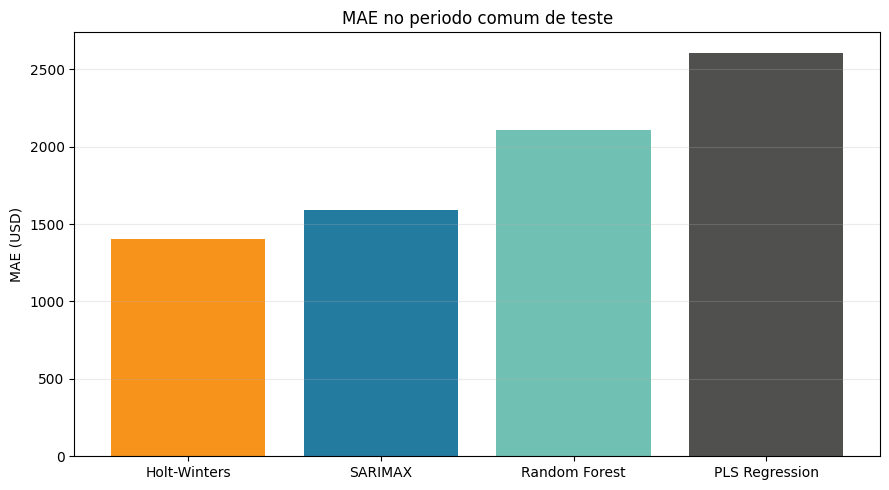

Periodo comum: 2024-05-09 a 2026-09-11 (856 previsoes)
        modelo     status  n_previsoes data_inicio   data_fim  MAE_reportado  MAE_periodo_comum  RMSE_periodo_comum  MAPE_periodo_comum_pct  R2_periodo_comum  n_periodo_comum inicio_periodo_comum fim_periodo_comum
  Holt-Winters Disponivel          883  2024-04-12 2026-09-11    1407.979460        1406.540849         1963.749080                1.703212          0.989227              856           2024-05-09        2026-09-11
PLS Regression Disponivel          856  2024-05-09 2026-09-11    2608.614507        2608.614507         3521.843601                3.157609          0.965351              856           2024-05-09        2026-09-11
 Random Forest Disponivel          856  2024-05-09 2026-09-11    2108.001665        2108.001665         2901.947396                2.543061          0.976475              856           2024-05-09        2026-09-11
       SARIMAX Disponivel          856  2024-05-09 2026-09-11    1590.770367        1590.

In [2]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

cwd = Path.cwd().resolve()
project_root = next(
    (path for path in (cwd, *cwd.parents)
     if (path / 'analyses').is_dir() and (path / 'bases').is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError('Nao foi possivel localizar a raiz do projeto.')

results_dir = project_root / 'analyses' / 'grupo1' / '03_resultados'
model_root = project_root / 'analyses' / 'grupo1' / '02_modelos'
results_dir.mkdir(parents=True, exist_ok=True)

models = {
    'Holt-Winters': {
        'directory': model_root / 'Holt_Winters',
        'forecast': 'hw_previsoes_walkforward.csv',
        'metrics': 'hw_metricas_walkforward.json',
        'prediction': 'priceClose_pred_HW',
    },
    'PLS Regression': {
        'directory': model_root / 'PLS_Regression',
        'forecast': 'pls_previsoes_walkforward.csv',
        'metrics': 'pls_metricas_walkforward.json',
        'prediction': 'priceClose_pred_PLS',
    },
    'Random Forest': {
        'directory': model_root / 'Random_Forest',
        'forecast': 'rf_previsoes_walkforward.csv',
        'metrics': 'rf_metricas_walkforward.json',
        'prediction': 'priceClose_pred_RF',
    },
    'SARIMAX': {
        'directory': model_root / 'SARIMAX',
        'forecast': 'sarimax_previsoes_walkforward.csv',
        'metrics': 'sarimax_metricas_walkforward.json',
        'prediction': 'priceClose_pred_SARIMAX',
    },
}

forecasts = {}
summary_rows = []
for model_name, spec in models.items():
    forecast_path = spec['directory'] / spec['forecast']
    metrics_path = spec['directory'] / spec['metrics']
    if not forecast_path.is_file():
        summary_rows.append({
            'modelo': model_name,
            'status': f'Pendente: arquivo ausente ({spec["forecast"]})',
            'n_previsoes': 0,
            'data_inicio': pd.NaT,
            'data_fim': pd.NaT,
            'MAE_reportado': np.nan,
            'MAE_periodo_comum': np.nan,
            'RMSE_periodo_comum': np.nan,
            'MAPE_periodo_comum_pct': np.nan,
            'R2_periodo_comum': np.nan,
        })
        continue

    frame = pd.read_csv(forecast_path, parse_dates=['date']).sort_values('date')
    if model_name == 'PLS Regression':
        frame['date'] = frame['date'] + pd.Timedelta(days=1)
    required = {'date', 'priceClose_real', spec['prediction']}
    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(f'{forecast_path} nao contem as colunas: {sorted(missing)}')
    frame = frame[['date', 'priceClose_real', spec['prediction']]].dropna()
    forecasts[model_name] = frame
    reported = json.loads(metrics_path.read_text(encoding='utf-8')) if metrics_path.is_file() else {}
    summary_rows.append({
        'modelo': model_name,
        'status': 'Disponivel',
        'n_previsoes': len(frame),
        'data_inicio': frame['date'].min(),
        'data_fim': frame['date'].max(),
        'MAE_reportado': reported.get('MAE', np.nan),
        'MAE_periodo_comum': np.nan,
        'RMSE_periodo_comum': np.nan,
        'MAPE_periodo_comum_pct': np.nan,
        'R2_periodo_comum': np.nan,
    })

if not forecasts:
    raise FileNotFoundError('Nenhum arquivo de previsoes walk-forward foi encontrado.')

common_dates = set.intersection(*(set(frame['date']) for frame in forecasts.values()))
if not common_dates:
    raise ValueError('Os modelos disponiveis nao compartilham datas de previsao.')
common_dates = sorted(common_dates)
common_truth = None
for model_name, frame in forecasts.items():
    aligned = frame[frame['date'].isin(common_dates)].set_index('date').sort_index()
    truth = aligned['priceClose_real'].astype(float)
    if common_truth is None:
        common_truth = truth
    elif not np.allclose(common_truth.to_numpy(), truth.to_numpy()):
        raise ValueError(f'Valores reais divergentes no periodo comum para {model_name}.')

    prediction = aligned[models[model_name]['prediction']].astype(float)
    row = next(item for item in summary_rows if item['modelo'] == model_name)
    row.update({
        'MAE_periodo_comum': mean_absolute_error(truth, prediction),
        'RMSE_periodo_comum': mean_squared_error(truth, prediction) ** 0.5,
        'MAPE_periodo_comum_pct': np.abs((truth - prediction) / truth).mean() * 100,
        'R2_periodo_comum': r2_score(truth, prediction),
        'n_periodo_comum': len(aligned),
        'inicio_periodo_comum': aligned.index.min(),
        'fim_periodo_comum': aligned.index.max(),
    })

mae_consolidado = pd.DataFrame(summary_rows)
mae_consolidado.to_csv(results_dir / 'mae_consolidado.csv', index=False)

available = mae_consolidado[mae_consolidado['status'].eq('Disponivel')].sort_values('MAE_periodo_comum')
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(available['modelo'], available['MAE_periodo_comum'], color=['#f7931a', '#247ba0', '#70c1b3', '#50514f'][:len(available)])
ax.set_title('MAE no periodo comum de teste')
ax.set_ylabel('MAE (USD)')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(results_dir / '01_mae_periodo_comum.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Periodo comum: {common_dates[0].date()} a {common_dates[-1].date()} ({len(common_dates)} previsoes)')
print(mae_consolidado.to_string(index=False))
print(f'\nTabela salva em: {results_dir / "mae_consolidado.csv"}')